# PASTIS .npy Profile Inspection

A quick, visual look at the raw `.npy` files themselves — shapes, dtypes,
value ranges, per-band distributions, and a season-long image filmstrip —
separate from the full EDA/training notebook. Change `PATCH_ID` below and
re-run to inspect a different patch.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_loading import load_config, load_metadata, list_patch_ids, load_s2, load_target, get_dates
from preprocessing import to_reflectance, compute_ndvi

cfg = load_config("configs/config.yaml")
gdf = load_metadata(cfg)
patch_ids = list_patch_ids(cfg)
band_names = [cfg["bands"][i]["band"] for i in range(cfg["data"]["n_bands"])]

PATCH_ID = patch_ids[0]   # <-- change this to inspect a different patch
print(f"{len(patch_ids)} patches available, e.g. {patch_ids[:8]} ...")
print(f"Inspecting PATCH_ID = {PATCH_ID}")

102 patches available, e.g. [30003, 30013, 30014, 30023, 30026, 30033, 30048, 30052] ...
Inspecting PATCH_ID = 30003


## Raw array profile (shape, dtype, value range)

In [2]:
s2_raw = load_s2(cfg, PATCH_ID)          # (T, C, H, W), int16, DN = reflectance x 10000
target_raw = np.load(f"../{cfg['data']['annotations_dir']}/TARGET_{PATCH_ID}.npy")  # raw (1, H, W)

print("S2 array (DATA_S2/S2_<id>.npy)")
print("  shape :", s2_raw.shape, " -> (T, C, H, W)")
print("  dtype :", s2_raw.dtype)
print("  min/max/mean:", s2_raw.min(), "/", s2_raw.max(), "/", f"{s2_raw.mean():.1f}")
print("  NaNs present:", np.isnan(s2_raw.astype(np.float64)).any())

print("\nTARGET array (ANNOTATIONS/TARGET_<id>.npy)")
print("  raw shape  :", target_raw.shape, " -> (annotation_layers, H, W); only layer 0 (semantic) is provided")
print("  dtype      :", target_raw.dtype)
print("  unique classes present:", sorted(np.unique(target_raw).tolist()))

dates = get_dates(gdf, PATCH_ID)
print(f"\n{len(dates)} acquisition dates, {dates[0]} to {dates[-1]}")

S2 array (DATA_S2/S2_<id>.npy)
  shape : (46, 10, 128, 128)  -> (T, C, H, W)
  dtype : int16
  min/max/mean: -105 / 14924 / 2092.0
  NaNs present: False

TARGET array (ANNOTATIONS/TARGET_<id>.npy)
  raw shape  : (1, 128, 128)  -> (annotation_layers, H, W); only layer 0 (semantic) is provided
  dtype      : uint8
  unique classes present: [0, 1, 2, 3, 4, 5, 12, 19]

46 acquisition dates, 2018-09-20 to 2019-10-25


## Per-band value profile (all timesteps, this patch)

In [3]:
refl = to_reflectance(s2_raw)  # (T, C, H, W), reflectance units

rows = []
for i, name in enumerate(band_names):
    band_vals = refl[:, i]
    rows.append({
        "band": name, "min": band_vals.min(), "p01": np.percentile(band_vals, 1),
        "mean": band_vals.mean(), "p99": np.percentile(band_vals, 99), "max": band_vals.max(),
        "std": band_vals.std(),
    })
band_profile = pd.DataFrame(rows).round(4)
band_profile

,band,min,p01,mean,p99,max,std
0,B2,0.0000,0.0000,0.1064,0.7979,1.4740,0.1912
1,B3,0.0000,0.0000,0.1248,0.8002,1.4924,0.1843
2,B4,0.0000,0.0000,0.1264,0.8173,1.4535,0.1915
3,B5,0.0000,0.0000,0.1598,0.8135,1.4255,0.1796
4,B6,0.0000,0.0212,0.2619,0.8432,1.3899,0.1659
5,B7,0.0000,0.0281,0.3005,0.8579,1.3756,0.1671
6,B8,0.0000,0.0314,0.3105,0.8400,1.3609,0.1669
7,B8A,0.0000,0.0355,0.3278,0.8670,1.3477,0.1657
8,B11,-0.0105,0.0126,0.2274,0.7269,1.1534,0.1375
9,B12,0.0000,0.0082,0.1465,0.5932,0.8693,0.1192


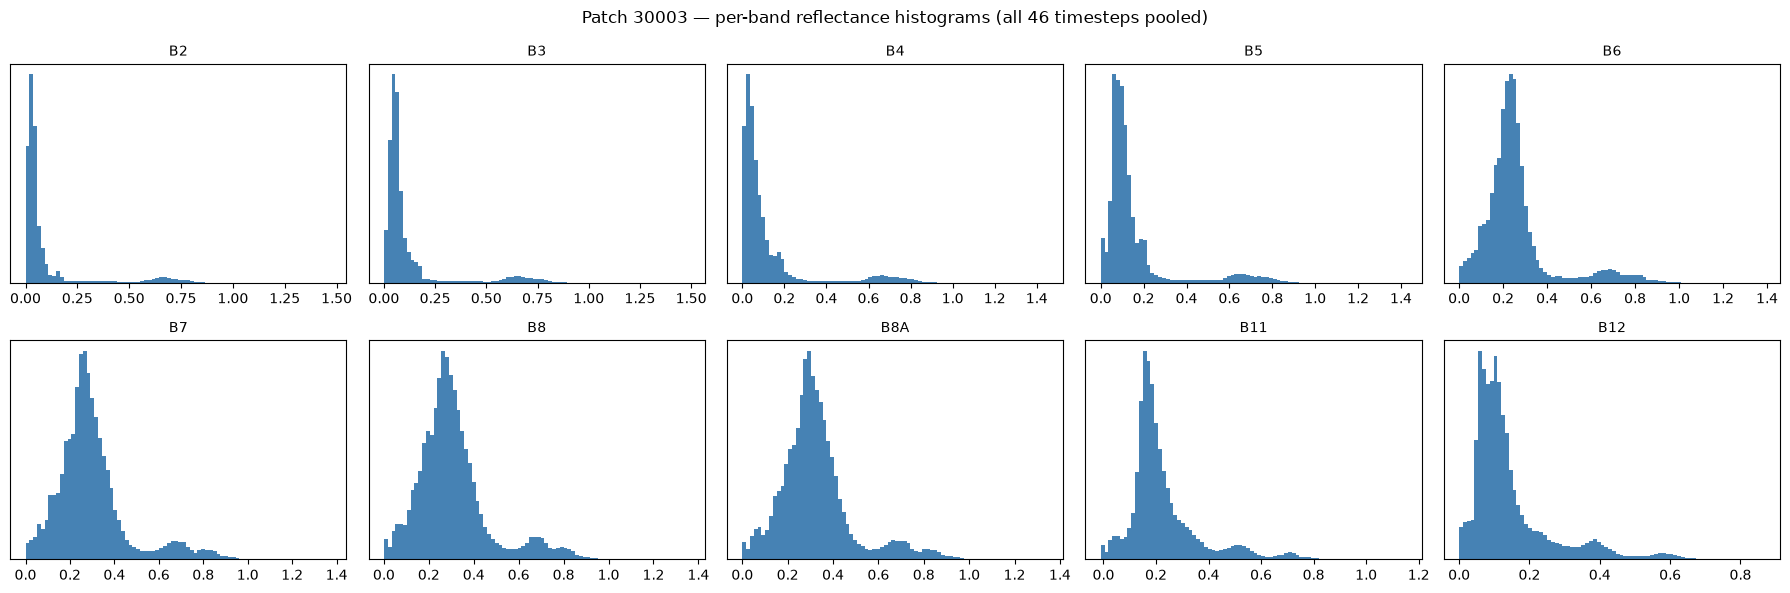

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for i, (name, ax) in enumerate(zip(band_names, axes.ravel())):
    ax.hist(refl[:, i].ravel(), bins=80, color="steelblue")
    ax.set_title(name, fontsize=10)
    ax.set_yticks([])
fig.suptitle(f"Patch {PATCH_ID} — per-band reflectance histograms (all {refl.shape[0]} timesteps pooled)")
plt.tight_layout()
plt.show()

## Per-timestep summary — spot cloud/outlier acquisitions

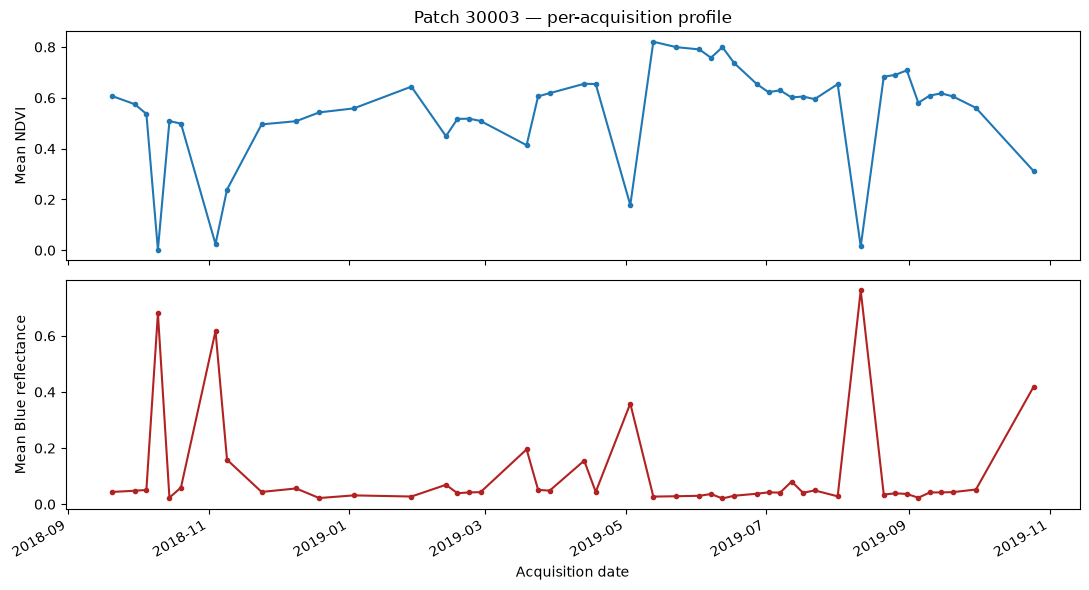

,obs,date,mean_ndvi,mean_blue
3,3,2018-10-10,0.002084,0.680470
36,36,2019-08-11,0.015196,0.761777
6,6,2018-11-04,0.024583,0.616875
22,22,2019-05-03,0.178228,0.358830
7,7,2018-11-09,0.239103,0.158516


In [5]:
ndvi = compute_ndvi(refl)  # (T, H, W)
per_t = pd.DataFrame({
    "obs": range(len(dates)),
    "date": dates,
    "mean_ndvi": ndvi.mean(axis=(1, 2)),
    "mean_blue": refl[:, 0].mean(axis=(1, 2)),   # bright/hazy frames show elevated blue reflectance
})
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(per_t["date"], per_t["mean_ndvi"], marker="o", ms=3)
axes[0].set_ylabel("Mean NDVI")
axes[0].set_title(f"Patch {PATCH_ID} — per-acquisition profile")
axes[1].plot(per_t["date"], per_t["mean_blue"], marker="o", ms=3, color="firebrick")
axes[1].set_ylabel("Mean Blue reflectance")
axes[1].set_xlabel("Acquisition date")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
per_t.sort_values("mean_ndvi").head(5)

A simultaneous NDVI dip + Blue-reflectance spike on the same date is the
usual signature of cloud/haze contamination on that acquisition (see the
main EDA notebook's Data Quality Checks section for the dataset-wide
version of this check).

## Season filmstrip — RGB composite every few acquisitions

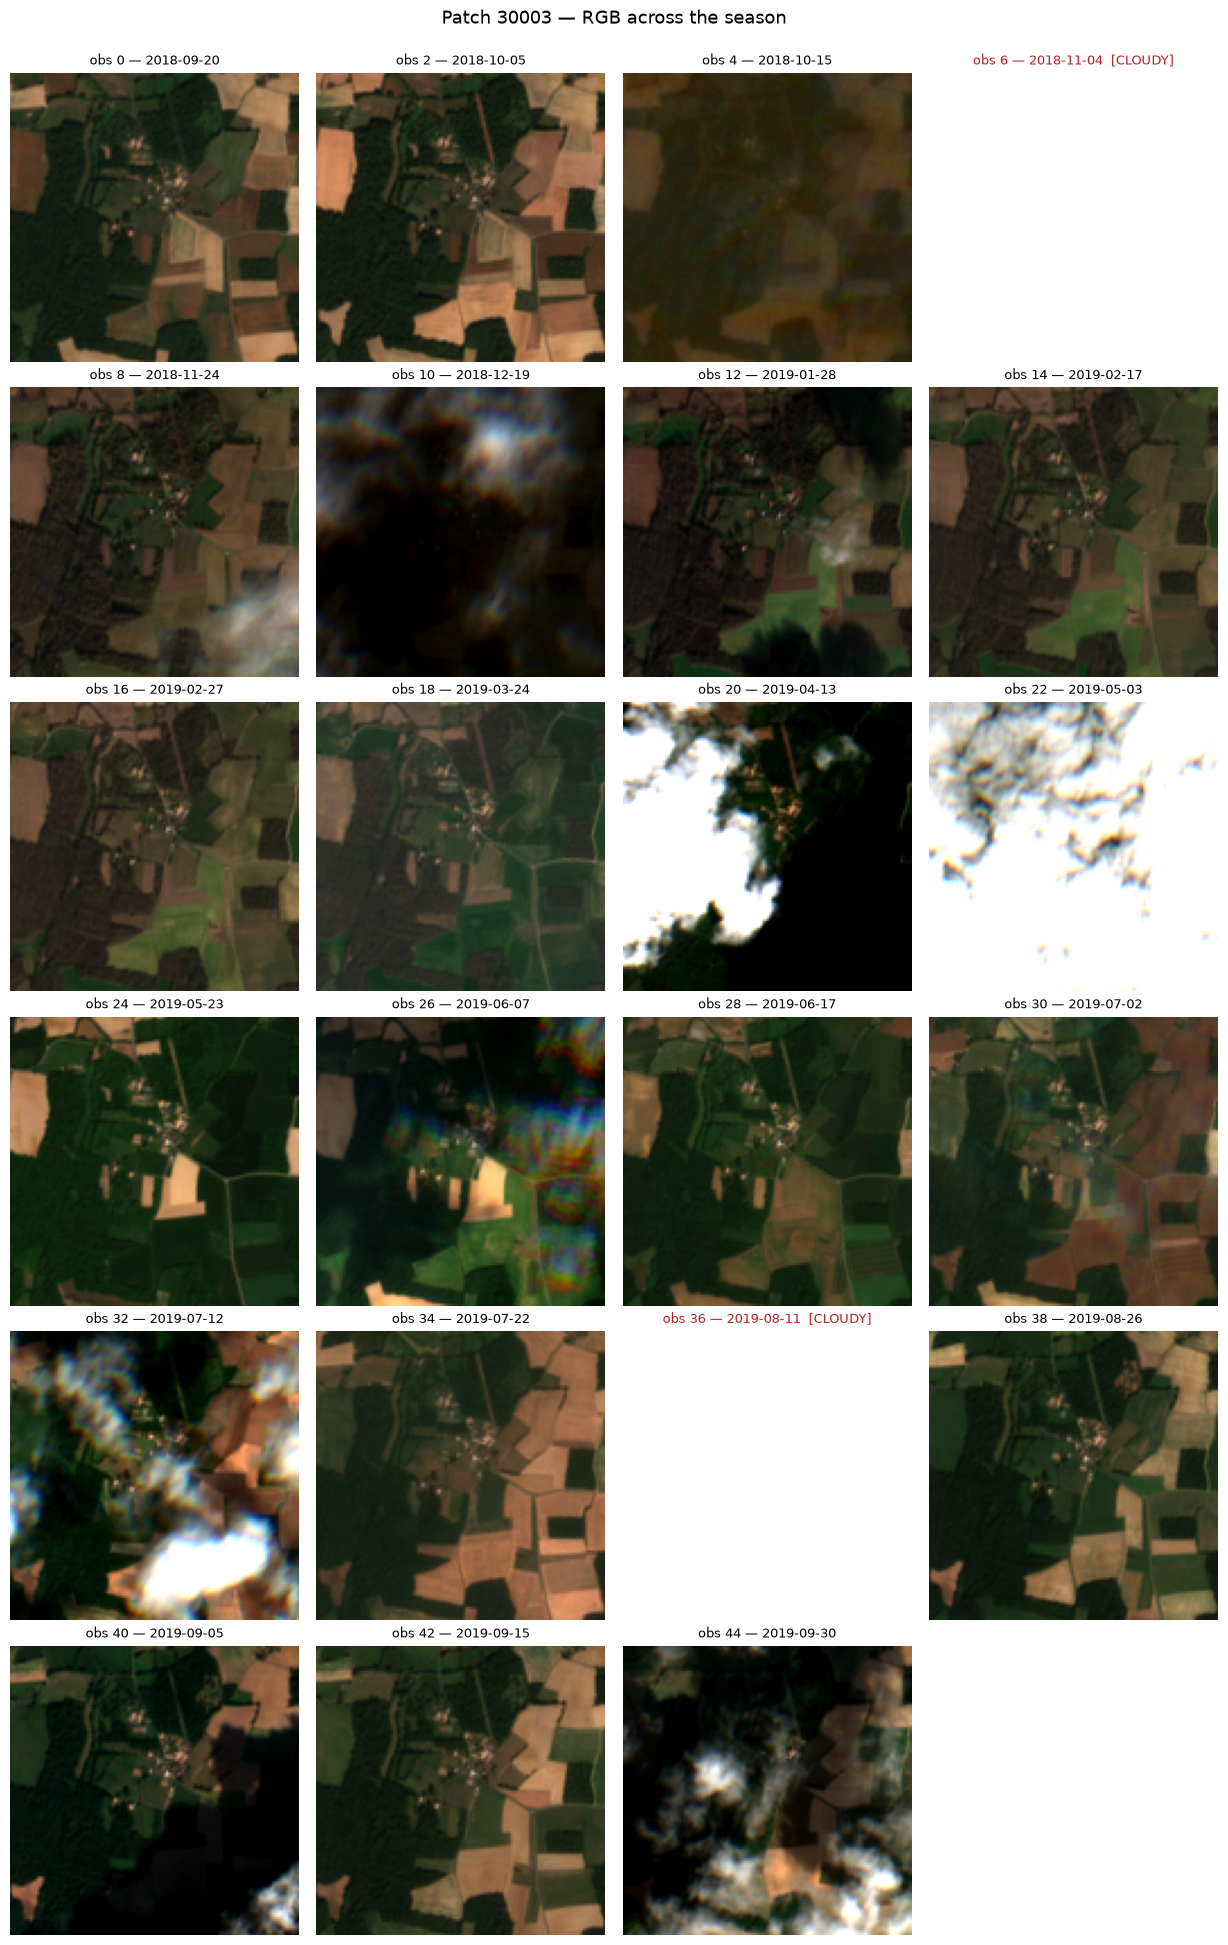

In [6]:
rgb_idx = cfg["rgb_bands"]
step = max(1, refl.shape[0] // 16)
frame_idxs = list(range(0, refl.shape[0], step))
n_cols = 4
n_rows = int(np.ceil(len(frame_idxs) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.1 * n_cols, 3.3 * n_rows))
for ax, t in zip(axes.ravel(), frame_idxs):
    rgb = np.clip(refl[t][rgb_idx].transpose(1, 2, 0) / 0.3, 0, 1)
    ax.imshow(rgb)
    # Near-white, near-zero-NDVI frames are fully cloud-covered scenes.
    flag = "  [CLOUDY]" if ndvi[t].mean() < 0.15 else ""
    ax.set_title(f"obs {t} — {dates[t]}{flag}", fontsize=9,
                 color=("firebrick" if flag else "black"))
    ax.axis("off")
for ax in axes.ravel()[len(frame_idxs):]:
    ax.axis("off")
fig.suptitle(f"Patch {PATCH_ID} — RGB across the season", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Frames flagged **[CLOUDY]** are near-fully cloud-covered — they render
almost pure white and their mean NDVI collapses toward 0. These are the same
acquisitions the NDVI/Blue profile above singles out, and they are exactly
the dates the main EDA notebook flags dataset-wide. Worth remembering that
a handful of the 46 "observations" carry almost no usable ground signal.

## Label map (raw target array)

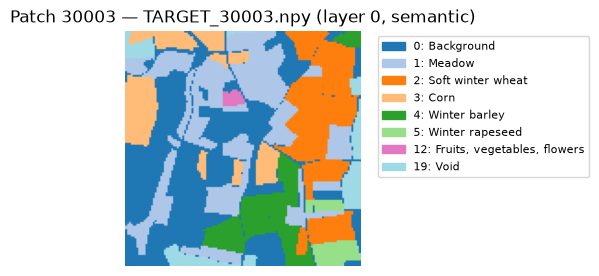

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(target_raw[0], cmap="tab20", vmin=0, vmax=19)
ax.set_title(f"Patch {PATCH_ID} — TARGET_{PATCH_ID}.npy (layer 0, semantic)")
ax.axis("off")
classes_present = sorted(np.unique(target_raw[0]).tolist())
handles = [plt.Rectangle((0, 0), 1, 1, color=plt.cm.tab20(c / 19)) for c in classes_present]
labels = [f"{c}: {cfg['classes'][c]}" for c in classes_present]
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## NDVI profile per class — this patch

Mean NDVI over the season for every class present in this patch, using the
same colors as the label map above. Shaded band = ±1 std across the pixels
of that class (wide = spectrally heterogeneous class or few pixels; the
per-class pixel count is in the legend). Grey vertical lines mark the
near-fully-clouded acquisitions detected earlier — dips that line up with
them are artifacts, not phenology.

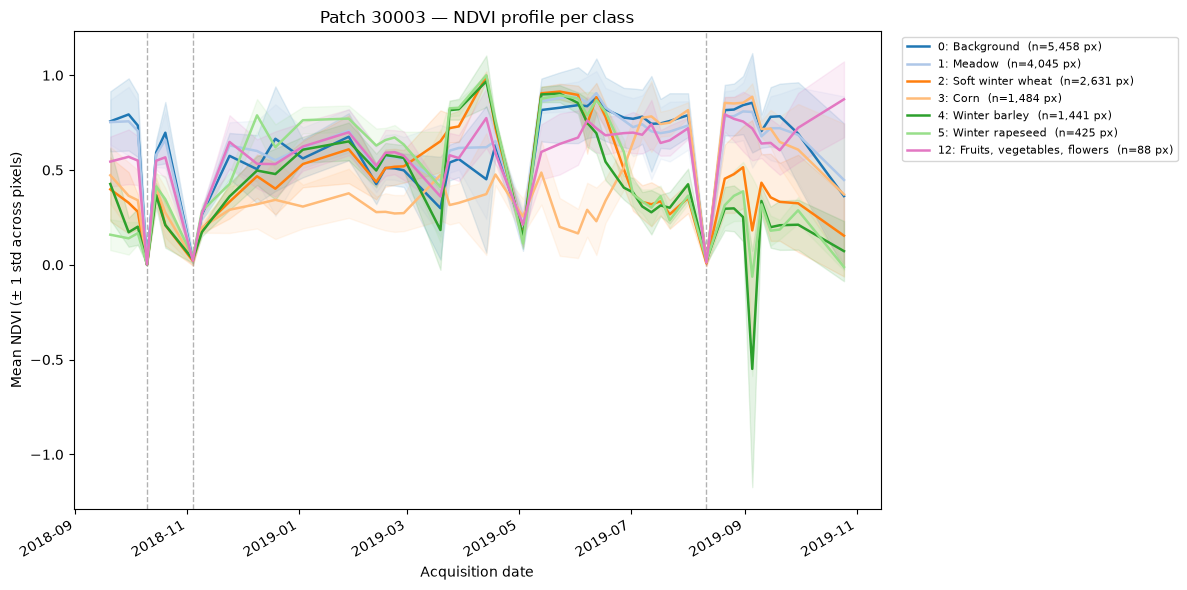

,class_id,class_name,n_pixels,ndvi_mean,ndvi_min,ndvi_max,peak_date
0,0,Background,5458,0.620,0.003,0.882,2019-06-12
1,1,Meadow,4045,0.629,0.002,0.906,2019-06-12
2,2,Soft winter wheat,2631,0.456,0.001,0.995,2019-04-13
3,3,Corn,1484,0.441,0.003,0.887,2019-09-05
4,4,Winter barley,1441,0.401,-0.549,0.968,2019-04-13
5,5,Winter rapeseed,425,0.459,-0.063,1.000,2019-04-13
6,12,"Fruits, vegetables, flowers",88,0.585,0.002,0.873,2019-10-25


: 

In [ ]:
void_class = cfg["void_class"]
classes_here = [c for c in np.unique(target_raw[0]).tolist() if c != void_class]
cloudy_t = [t for t in range(len(dates)) if ndvi[t].mean() < 0.15]

fig, ax = plt.subplots(figsize=(12, 6))
for t in cloudy_t:
    ax.axvline(dates[t], color="grey", ls="--", lw=1, alpha=0.6, zorder=0)

rows = []
for c in classes_here:
    mask = target_raw[0] == c
    series = ndvi[:, mask]                 # (T, n_pixels_of_this_class)
    mean_curve, std_curve = series.mean(axis=1), series.std(axis=1)
    color = plt.cm.tab20(c / 19)
    ax.plot(dates, mean_curve, color=color, lw=1.8,
            label=f"{c}: {cfg['classes'][c]}  (n={mask.sum():,} px)")
    ax.fill_between(dates, mean_curve - std_curve, mean_curve + std_curve,
                    color=color, alpha=0.12)
    rows.append({"class_id": c, "class_name": cfg["classes"][c], "n_pixels": int(mask.sum()),
                 "ndvi_mean": mean_curve.mean(), "ndvi_min": mean_curve.min(),
                 "ndvi_max": mean_curve.max(), "peak_date": dates[int(mean_curve.argmax())]})

ax.set_xlabel("Acquisition date")
ax.set_ylabel("Mean NDVI (\u00b1 1 std across pixels)")
ax.set_title(f"Patch {PATCH_ID} — NDVI profile per class")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

pd.DataFrame(rows).round(3)

Reading this: a class peaking in **spring** and senescing before summer is
a winter-sown crop (wheat, barley, rapeseed); one that stays low through
winter and peaks in **July-August** is a summer crop (corn, soybean,
sunflower). Because this is a single patch, curves here come from just a
handful of parcels each, so they are noisier than the dataset-wide version
in the main EDA notebook — useful for eyeballing one patch, not for drawing
conclusions about a class in general.